## t-SNE

Unsupervised Data Projection 384-dimensional embeddings in 2D, for 10,000 datapoints

sklearn.manifold.TSNE:
https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html

This technique performs non-linear dimensionality reduction by minimizing the Kullback-Leibler divergence between the pairwise similarity distributions of the original high-dimensional space and the target low-dimensional space, minimizing the cost function $$C = \sum_{i \neq j} p_{ij} \log \frac{p_{ij}}{q_{ij}}$$.

For practical implementations and the theoretical foundation, consider the following reference:

Visualizing Data using t-SNE (van der Maaten & Hinton, 2008): The canonical manuscript introducing the probabilistic framework of the algorithm and its efficacy on various high-dimensional datasets:

https://www.jmlr.org/papers/volume9/vandermaaten08a/vandermaaten08a.pdf

In [ ]:
import os
from sentence_transformers import SentenceTransformer # For calculating Embeddings of 10,000 samples.
import pandas as pd
import numpy as np

#os.environ["HF_TOKEN"] = ""
df = pd.read_json("../data/processed/mmlu_t1.0_n20.jsonl", lines=True)
all_responses = df["model_answer"]

# Embedding the responses of a dataset in R^384
model = SentenceTransformer("all-MiniLM-L6-v2")
E = model.encode(all_responses, batch_size=256, show_progress_bar=True, normalize_embeddings=True) # E.shape = (10000, 384)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/40 [00:00<?, ?it/s]

In [24]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
from sklearn.manifold import TSNE
import sys
import os

tsne = TSNE(n_components=2, perplexity=30.0, metric="cosine", init="pca", random_state=42)
Z = tsne.fit_transform(E)

df = pd.read_json("../data/processed/mmlu_t1.0_n20.jsonl", lines=True)

# Append 2D coordinates 
df["z1"] = Z[:, 0]
df["z2"] = Z[:, 1]
label_colors = {0: "green", 1: "red"}

parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(parent_dir)
from spectral_detection.analysis.eda import compute_majority_valid_domain

# The LLM Judge has placed some spurious values in the domain field of the JSON files
# This is corrected below

computed_modes = df.groupby('question')['domain'].apply(compute_majority_valid_domain)
df['domain_clean'] = df['question'].map(computed_modes)

In [26]:
# It seems some domains are N/A so we simply fill it with miscellaneous
residual_domain = "Law, Business, and Miscellaneous"
df['domain_clean'] = df['domain_clean'].fillna(residual_domain)
print("Unique domains post-transformation:")
print(df['domain_clean'].unique())

Unique domains post-transformation:
<ArrowStringArray>
[                            'STEM',                'Medicine & Health',
                  'Social Sciences',                       'Humanities',
 'Law, Business, and Miscellaneous']
Length: 5, dtype: str


In [27]:
# Selecting 1 confident, partial (mid-way), or really bad hallucinations for the plot
df['y_hat'] = (df['correctness'] == 'incorrect').astype(int) # ==> Convert 'correct' or 'incorrect' into 0 or 1
question_stats = df.groupby(['question', 'domain_clean']).agg(p_hat=('y_hat', 'mean')).reset_index()
confident_correct = question_stats[question_stats['p_hat'] < 0.2]
partial_hallucination = question_stats[(question_stats['p_hat'] > 0.4) & (question_stats['p_hat'] <= 0.5)]
heavy_hallucination = question_stats[question_stats['p_hat'] >= 0.9]
selected_questions = []

# Sample n=1 from each
s_confident = confident_correct.sample(1, random_state=42) if not confident_correct.empty else pd.DataFrame()
s_partial = partial_hallucination.sample(1, random_state=42) if not partial_hallucination.empty else pd.DataFrame()
s_heavy = heavy_hallucination.sample(1, random_state=42) if not heavy_hallucination.empty else pd.DataFrame()

# Construct the selected subset of 3 questions, one confident, one partial hallucination, one heavy hallucination
s_df = pd.concat([s_confident, s_partial, s_heavy])
selected_questions = s_df['question'].tolist()
selected_questions

['A pita is a type of what?',
 'The mental retardation associated with PKU is preventable with:',
 "Which of the following best describes Lon Fuller's objective in his hypothetical case of the Speluncean Explorers?"]

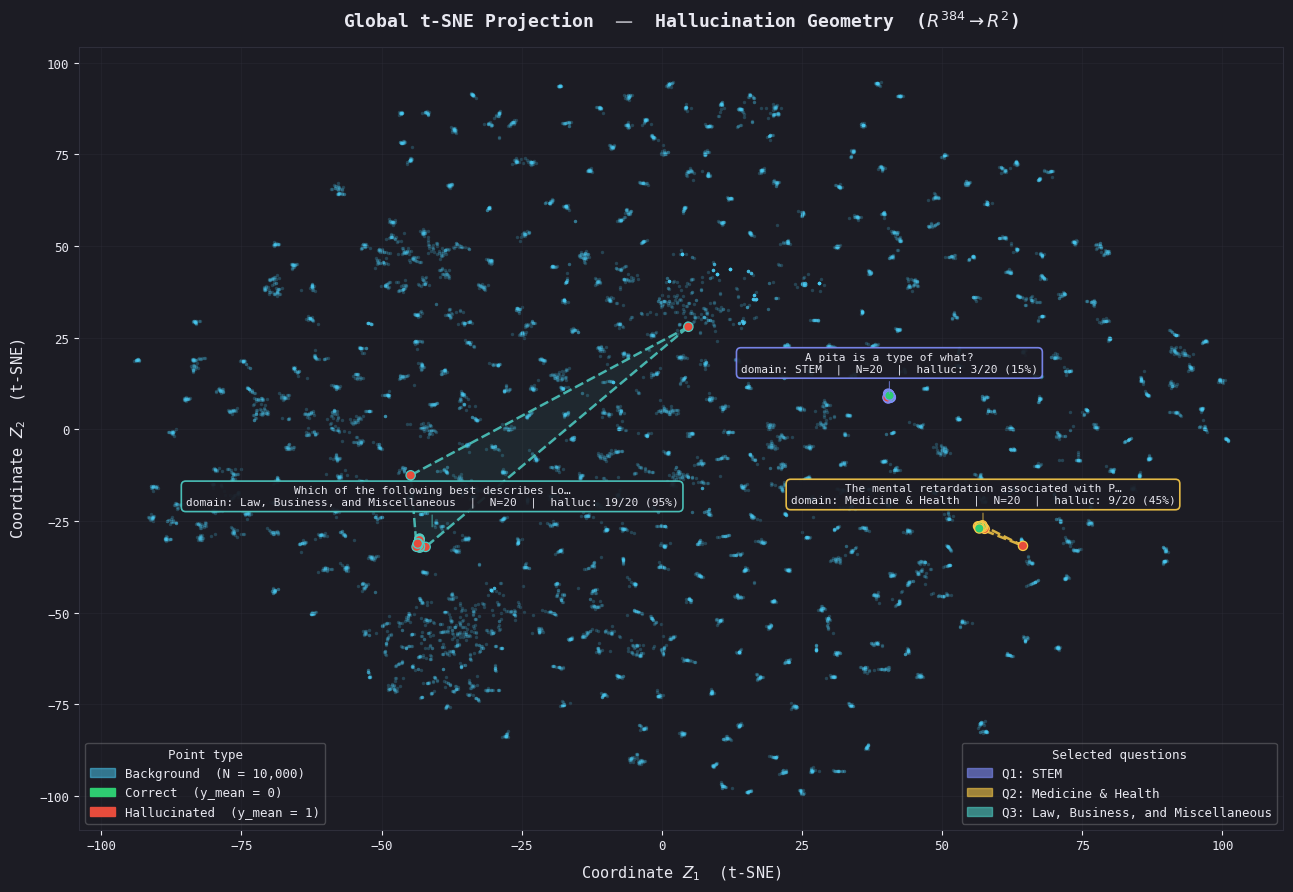

In [ ]:
# Global t-SNE Projection  —  Hallucination Geometry
# 10,000 samples embedded in R^384, projected to R^2.
# Selected questions are highlighted with hulls and correctness.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from scipy.spatial import ConvexHull
import warnings
warnings.filterwarnings("ignore")

# STYLE
BG       = "#1c1c24"    # dark charcoal (slightly lighter than pure black)
GRID     = "#2e2e3a"
TEXT     = "#e8e8f0"
C_BG_PTS = "#4bd0f9"    # 10k background cloud
C_CORRECT = "#2ecc71"   # green  — correct answers
C_HALLUC  = "#e74c3c"   # red    — hallucinated answers

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor":   BG,
    "axes.edgecolor":   GRID,
    "axes.labelcolor":  TEXT,
    "xtick.color":      TEXT,
    "ytick.color":      TEXT,
    "text.color":       TEXT,
    "grid.color":       GRID,
    "font.family":      "monospace",
    "font.size":        9,
})

# COLOUR PALETTE  —  one distinct accent per selected question
# Use a qualitatively distinct palette so hulls are visually separable.
HULL_PALETTE = [
    "#7f8cf7",   # lavender-blue
    "#f7c948",   # amber
    "#4ecdc4",   # teal
    "#ff6b6b",   # coral
    "#a29bfe",   # purple
    "#55efc4",   # mint
    "#fd79a8",   # pink
    "#fdcb6e",   # peach
]

# FIGURE
fig, ax = plt.subplots(figsize=(13, 9))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

# Background cloud
ax.scatter(
    df["z1"], df["z2"],
    color=C_BG_PTS, alpha=0.22, s=6, linewidths=0,
    rasterized=True,           
    label=f"Background  (N = {len(df):,})",
    zorder=1,
)

# Selected questions 
hull_legend_handles = []

for i, q in enumerate(selected_questions):
    q_data   = df[df["question"] == q]
    points   = q_data[["z1", "z2"]].values
    y_labels = q_data["y_hat"].values
    domain   = q_data["domain_clean"].iloc[0]
    n_total  = len(q_data)
    n_halluc = int(y_labels.sum())
    pct_h    = 100 * n_halluc / n_total if n_total > 0 else 0

    hull_colour = HULL_PALETTE[i % len(HULL_PALETTE)]

    # Per-point correctness colouring (green/red), hull-coloured edge ring
    pt_colors = [C_CORRECT if y == 0 else C_HALLUC for y in y_labels]
    ax.scatter(
        points[:, 0], points[:, 1],
        c=pt_colors, s=45, zorder=5,
        edgecolors=hull_colour, linewidths=0.9,
    )

    # Convex hull outline
    if len(points) >= 3:
        try:
            hull = ConvexHull(points)
            verts = np.append(hull.vertices, hull.vertices[0])   # close the loop
            ax.plot(
                points[verts, 0], points[verts, 1],
                color=hull_colour, lw=1.8, linestyle="--",
                alpha=0.85, zorder=4,
            )
            # Translucent fill
            ax.fill(
                points[hull.vertices, 0], points[hull.vertices, 1],
                color=hull_colour, alpha=0.07, zorder=3,
            )
        except Exception:
            pass

    # Annotation box: question text + domain + hallucination rate
    center   = points.mean(axis=0)
    q_short  = (q[:40] + "…") if len(q) > 40 else q
    ann_text = (f"{q_short}\n"
                f"domain: {domain}  |  N={n_total}  |  "
                f"halluc: {n_halluc}/{n_total} ({pct_h:.0f}%)")

    ax.annotate(
        ann_text,
        xy=center,
        xytext=(0, 18), textcoords="offset points",
        fontsize=8, ha="center", color=TEXT,
        bbox=dict(boxstyle="round,pad=0.4",
                  fc=BG, ec=hull_colour, alpha=0.92, lw=1.2),
        arrowprops=dict(arrowstyle="-", color=hull_colour,
                        lw=0.8, alpha=0.7),
        zorder=7,
    )

    # Hull legend entry
    hull_legend_handles.append(
        mpatches.Patch(facecolor=hull_colour, edgecolor=hull_colour,
                       alpha=0.6, label=f"Q{i+1}: {domain}")
    )

# Grid lines
ax.grid(True, color=GRID, linewidth=0.5, alpha=0.5, zorder=0)

# Axis labels & title 
ax.set_xlabel("Coordinate $Z_1$  (t-SNE)", fontsize=11, labelpad=8)
ax.set_ylabel("Coordinate $Z_2$  (t-SNE)", fontsize=11, labelpad=8)
ax.set_title(
    r"Global t-SNE Projection  —  Hallucination Geometry  "
    r"($\mathbb{R}^{384} \rightarrow \mathbb{R}^{2}$)",
    fontsize=13, color=TEXT, pad=14, fontweight="bold",
)

# Legend 
dot_correct = mpatches.Patch(color=C_CORRECT,  label="Correct  (y_mean = 0)")
dot_halluc  = mpatches.Patch(color=C_HALLUC,   label="Hallucinated  (y_mean = 1)")
dot_bg      = mpatches.Patch(color=C_BG_PTS,   label=f"Background  (N = {len(df):,})",
                              alpha=0.5)

# Two-section legend: left = point types, right = per-question hull colours
leg1 = ax.legend(
    handles=[dot_bg, dot_correct, dot_halluc],
    loc="lower left", framealpha=0.25, fontsize=9,
    title="Point type", title_fontsize=9,
)
ax.add_artist(leg1)   # keep it when adding second legend

ax.legend(
    handles=hull_legend_handles,
    loc="lower right", framealpha=0.25, fontsize=9,
    title="Selected questions", title_fontsize=9,
    ncol=max(1, len(hull_legend_handles) // 4),
)

plt.tight_layout()
plt.show()

## Fig 1:  Convex hulls of hallucinated clusters vs compact correct clusters, mapped by t-SNE in 2D

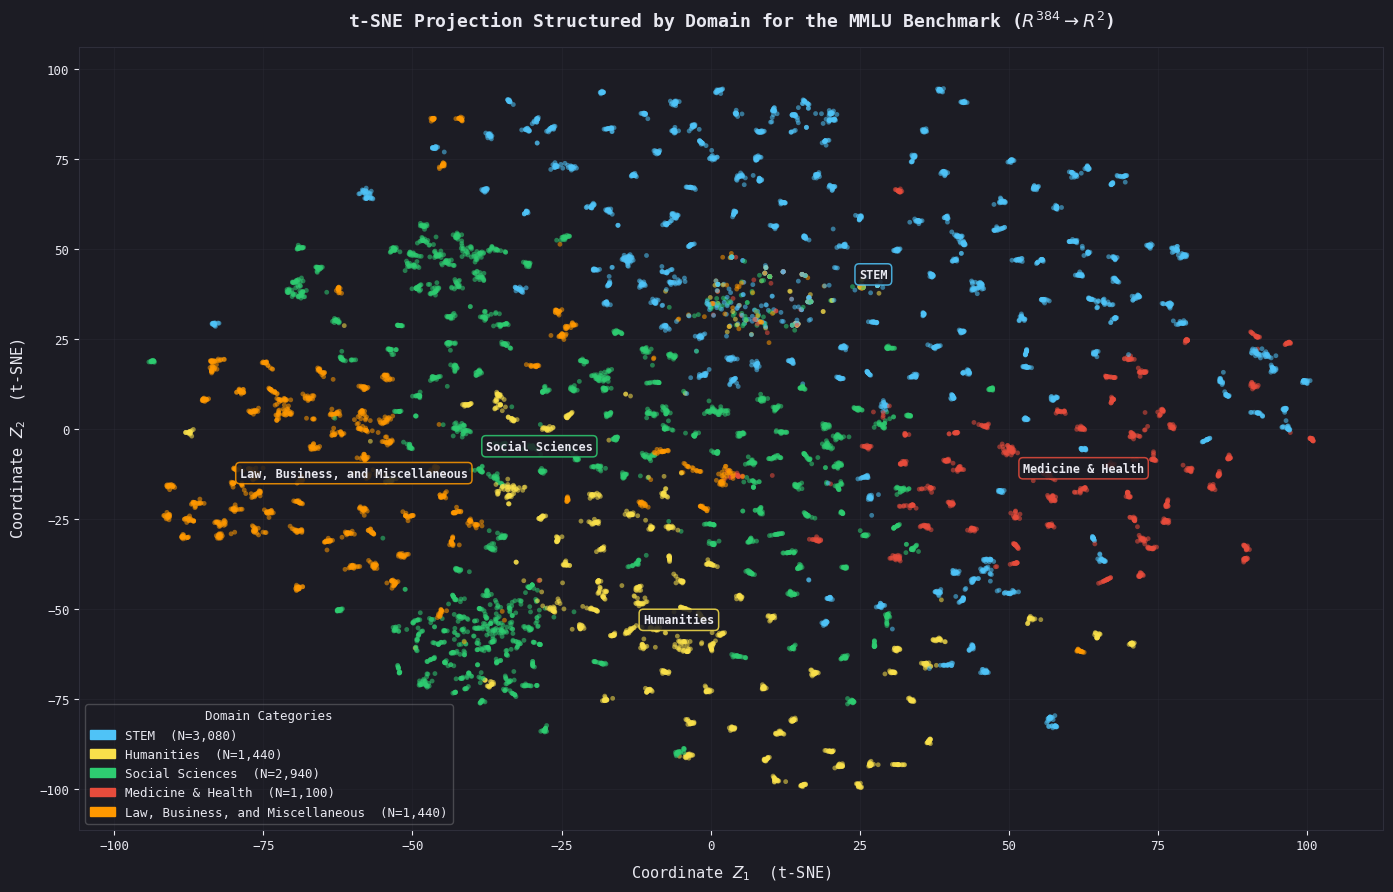

In [34]:
# Topical Manifold  —  Global t-SNE coloured by domain

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import warnings
warnings.filterwarnings("ignore")

# STYLE
BG   = "#1c1c24"
GRID = "#2e2e3a"
TEXT = "#e8e8f0"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor":   BG,
    "axes.edgecolor":   GRID,
    "axes.labelcolor":  TEXT,
    "xtick.color":      TEXT,
    "ytick.color":      TEXT,
    "text.color":       TEXT,
    "grid.color":       GRID,
    "font.family":      "monospace",
    "font.size":        9,
})

# DOMAIN COLOURS
domain_to_color = {
    "STEM":                              "#4fc3f7",   # sky blue
    "Humanities":                        "#f9e04b",   # bright yellow
    "Social Sciences":                   "#2ecc71",   # green
    "Medicine & Health":                 "#e74c3c",   # red
    "Law, Business, and Miscellaneous":  "#ff9800",   # orange
}

# FIGURE
fig, ax = plt.subplots(figsize=(14, 9))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

# Compute axis extent once for the KDE grid
x_all, y_all = df["z1"].values, df["z2"].values
pad = (np.ptp(x_all) + np.ptp(y_all)) * 0.03
xmin, xmax = x_all.min() - pad, x_all.max() + pad
ymin, ymax = y_all.min() - pad, y_all.max() + pad

# Scatter: points colors by domain 
point_colors = df["domain_clean"].map(domain_to_color)
ax.scatter(
    df["z1"], df["z2"],
    c=point_colors, alpha=0.55, s=12,
    linewidths=0, rasterized=True, zorder=3,
)

# Domain centroid labels
for domain, hex_col in domain_to_color.items():
    sub = df[df["domain_clean"] == domain]
    if len(sub) < 5:
        continue
    cx, cy = sub["z1"].median(), sub["z2"].median()
    ax.text(cx, cy, domain,
            fontsize=8.5, color=TEXT, fontweight="bold",
            ha="center", va="center",
            bbox=dict(boxstyle="round,pad=0.35",
                      fc=BG, ec=hex_col, alpha=0.85, lw=1.1),
            zorder=5)

# Grid
ax.grid(True, color=GRID, linewidth=0.5, alpha=0.5, zorder=0)

# Labels & title
ax.set_xlabel("Coordinate $Z_1$  (t-SNE)", fontsize=11, labelpad=8)
ax.set_ylabel("Coordinate $Z_2$  (t-SNE)", fontsize=11, labelpad=8)
ax.set_title(
    r"t-SNE Projection Structured by Domain for the MMLU Benchmark "
    r"($R^{384} \rightarrow R^{2}$)",
    fontsize=13, color=TEXT, pad=14, fontweight="bold",
)

# Legend
legend_patches = [
    mpatches.Patch(color=color,
                   label=f"{domain}  (N={len(df[df['domain_clean']==domain]):,})")
    for domain, color in domain_to_color.items()
]
ax.legend(handles=legend_patches,
          title="Domain Categories", title_fontsize=9,
          loc="best", fontsize=9, framealpha=0.25)

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

plt.tight_layout()
plt.show()

## Fig 2:  Unsupervised t-SNE captures a general visual partition of domains:  embeddings training may be the culprit?  This is a question for a second project! 